# Step 1: Data Exploration & Classical Baseline (Multi-Lot Encoding)
## YQuantum 2026 — Capgemini / The Hartford Challenge

### Encoding: 4 Assets × 2 Qubits = 8 Qubits

Each asset gets **4 allocation levels** (0, 1, 2, 3 lots) encoded with 2 qubits:

| Qubit pair (MSB, LSB) | Lots | Weight |
|:---:|:---:|:---:|
| (0, 0) | 0 | 0 |
| (0, 1) | 1 | w_max / 3 |
| (1, 0) | 2 | 2·w_max / 3 |
| (1, 1) | 3 | w_max |

This gives **finer-grained weight control** compared to a simple binary include/exclude on 8 assets.

---

In [1]:
!pip install openpyxl seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import seaborn as sns
import json
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 1.1 Load Dataset

In [6]:
xlsx_path = 'investment_dataset_full.xlsx'

assets = pd.read_excel(xlsx_path, sheet_name='assets')
cov_df = pd.read_excel(xlsx_path, sheet_name='covariance', index_col=0)
corr_df = pd.read_excel(xlsx_path, sheet_name='correlation', index_col=0)
scenarios = pd.read_excel(xlsx_path, sheet_name='scenarios')

print(f'Assets: {assets.shape[0]}, Covariance: {cov_df.shape}, Scenarios: {scenarios.shape}')
print(f'\nSector breakdown:')
print(assets['sector'].value_counts().to_string())

Assets: 50, Covariance: (50, 50), Scenarios: (1200, 50)

Sector breakdown:
sector
IG Credit         12
Equities US       10
HY Credit         10
Equities Intl      7
Gov Bonds          5
Cash               3
Real Estate        2
Infrastructure     1


In [5]:
import sys
!{sys.executable} -m pip install openpyxl

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: /usr/local/bin/python3.13 -m pip install --upgrade pip


## 1.2 Risk-Return Landscape (All 50 Assets)

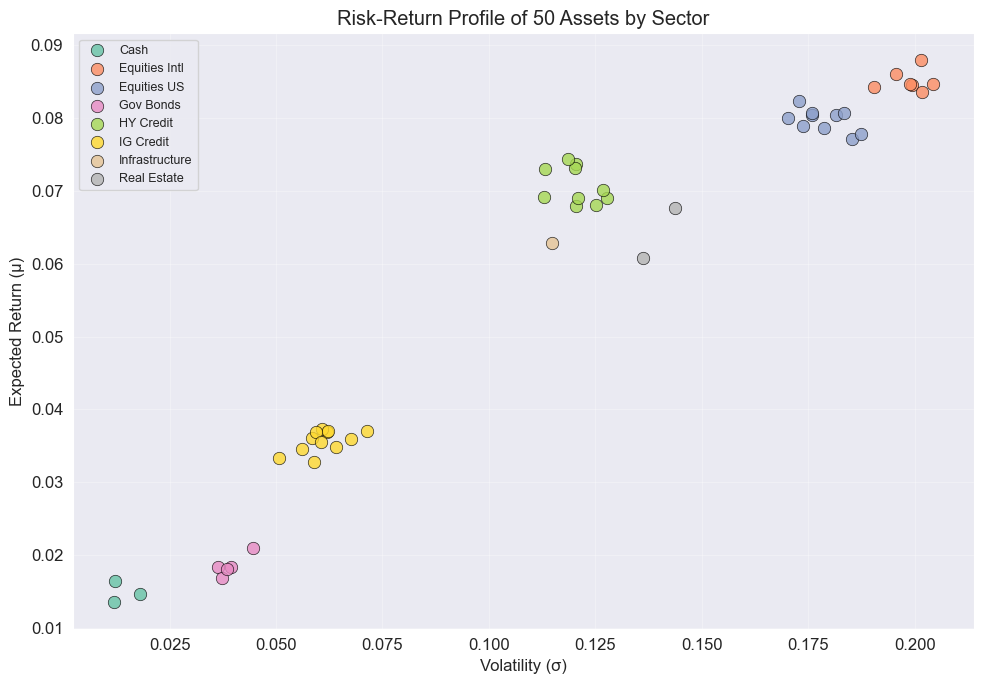

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.Set2(np.linspace(0, 1, assets['sector'].nunique()))
sector_colors = dict(zip(sorted(assets['sector'].unique()), colors))

for sector, group in assets.groupby('sector'):
    ax.scatter(group['volatility'], group['exp_return'], 
              c=[sector_colors[sector]], label=sector, s=80, alpha=0.8, 
              edgecolors='black', linewidth=0.5)

ax.set_xlabel('Volatility (σ)')
ax.set_ylabel('Expected Return (μ)')
ax.set_title('Risk-Return Profile of 50 Assets by Sector')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.3 Select 4 Assets (1 per Sector, Best Sharpe)

We pick 4 diverse sectors that span the risk spectrum:
- **Equities US** (high return, high risk)
- **HY Credit** (medium-high return, medium risk)
- **IG Credit** (medium return, low risk)
- **Gov Bonds** (low return, lowest risk)

In [8]:
assets['sharpe'] = assets['exp_return'] / assets['volatility']

target_sectors = ['Equities US', 'HY Credit', 'IG Credit', 'Gov Bonds']

selected_4 = []
for sector in target_sectors:
    subset = assets[assets['sector'] == sector]
    best = subset.loc[subset['sharpe'].idxmax()]
    selected_4.append(best)

sel4_df = pd.DataFrame(selected_4).set_index('asset_id')
sel4_ids = sel4_df.index.tolist()
sectors4 = sel4_df['sector'].tolist()

print('Selected 4 Assets:')
sel4_df[['sector', 'rating', 'exp_return', 'volatility', 'sharpe', 
         'liquidity', 'capital_charge', 'w_min', 'w_max']].round(4)

Selected 4 Assets:


,sector,rating,exp_return,volatility,sharpe,liquidity,capital_charge,w_min,w_max
asset_id,,,,,,,,,
A004,Equities US,NaN,0.0823,0.1729,0.4760,5,0.35,0,0.08
A047,HY Credit,B,0.0730,0.1132,0.6446,3,0.07,0,0.06
A026,IG Credit,A,0.0334,0.0508,0.6576,4,0.02,0,0.12
A017,Gov Bonds,AA,0.0183,0.0364,0.5031,4,0.01,0,0.20


In [9]:
# Extract numerical vectors
mu = sel4_df['exp_return'].values
w_max = sel4_df['w_max'].values
cov4 = cov_df.loc[sel4_ids, sel4_ids].values
corr4 = corr_df.loc[sel4_ids, sel4_ids].values
n_assets = 4
n_qubits = 8
K = 3  # max lot count

print(f'Expected returns μ:  {np.round(mu, 4)}')
print(f'Max weights w_max:   {w_max}')
print(f'Max total weight:    {w_max.sum():.2f}')
print(f'\n4×4 Covariance matrix:')
print(np.round(cov4, 6))

Expected returns μ:  [0.0823 0.073  0.0334 0.0183]
Max weights w_max:   [0.08 0.06 0.12 0.2 ]
Max total weight:    0.46

4×4 Covariance matrix:
[[0.029908 0.00067  0.000755 0.000102]
 [0.00067  0.012822 0.000518 0.000231]
 [0.000755 0.000518 0.002579 0.000234]
 [0.000102 0.000231 0.000234 0.001327]]


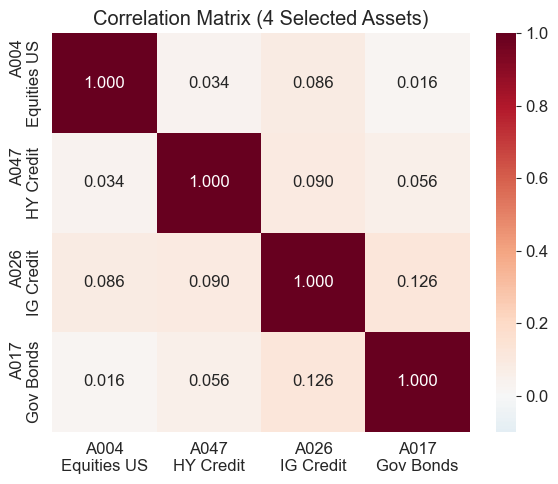

In [10]:
# Correlation heatmap for the 4 selected assets
fig, ax = plt.subplots(figsize=(6, 5))
labels = [f'{sid}\n{sec}' for sid, sec in zip(sel4_ids, sectors4)]
sns.heatmap(corr4, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            xticklabels=labels, yticklabels=labels, vmin=-0.1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix (4 Selected Assets)')
plt.tight_layout()
plt.show()

## 1.4 Multi-Lot Qubit Encoding

Each asset $i$ is encoded by 2 qubits: $(x_{2i}, x_{2i+1})$ where:

$$\text{lot\_count}_i = x_{2i} + 2 \cdot x_{2i+1}$$

$$w_i = \frac{\text{lot\_count}_i}{K} \cdot w_{\max,i} = \underbrace{\frac{w_{\max,i}}{K}}_{c_{2i}} \cdot x_{2i} \;+\; \underbrace{\frac{2 \, w_{\max,i}}{K}}_{c_{2i+1}} \cdot x_{2i+1}$$

In [11]:
# Weight coefficient per qubit
c = np.zeros(n_qubits)
for i in range(n_assets):
    c[2*i]     = w_max[i] / K       # LSB → 1 lot
    c[2*i + 1] = 2 * w_max[i] / K   # MSB → 2 lots

qubit_labels = ['A004_LSB', 'A004_MSB', 'A047_LSB', 'A047_MSB', 
                'A026_LSB', 'A026_MSB', 'A017_LSB', 'A017_MSB']

print('=== Qubit Encoding Map ===')
print(f'{"Qubit":>6} {"Label":>10} {"Asset":>6} {"Sector":>12} {"Bit":>4} {"Coeff c":>10} {"Meaning"}')
for q in range(n_qubits):
    asset_i = q // 2
    bit = 'LSB' if q % 2 == 0 else 'MSB'
    lots_val = 1 if q % 2 == 0 else 2
    print(f'{q:>6} {qubit_labels[q]:>10} {sel4_ids[asset_i]:>6} {sectors4[asset_i]:>12} '
          f'{bit:>4} {c[q]:>10.6f} → {lots_val} lot(s) = weight {c[q]:.4f}')

print(f'\nPossible weight levels per asset:')
for i in range(n_assets):
    levels = [0, w_max[i]/3, 2*w_max[i]/3, w_max[i]]
    print(f'  {sel4_ids[i]} ({sectors4[i]}): {[round(l, 4) for l in levels]}')

=== Qubit Encoding Map ===
 Qubit      Label  Asset       Sector  Bit    Coeff c Meaning
     0   A004_LSB   A004  Equities US  LSB   0.026667 → 1 lot(s) = weight 0.0267
     1   A004_MSB   A004  Equities US  MSB   0.053333 → 2 lot(s) = weight 0.0533
     2   A047_LSB   A047    HY Credit  LSB   0.020000 → 1 lot(s) = weight 0.0200
     3   A047_MSB   A047    HY Credit  MSB   0.040000 → 2 lot(s) = weight 0.0400
     4   A026_LSB   A026    IG Credit  LSB   0.040000 → 1 lot(s) = weight 0.0400
     5   A026_MSB   A026    IG Credit  MSB   0.080000 → 2 lot(s) = weight 0.0800
     6   A017_LSB   A017    Gov Bonds  LSB   0.066667 → 1 lot(s) = weight 0.0667
     7   A017_MSB   A017    Gov Bonds  MSB   0.133333 → 2 lot(s) = weight 0.1333

Possible weight levels per asset:
  A004 (Equities US): [0, np.float64(0.0267), np.float64(0.0533), np.float64(0.08)]
  A047 (HY Credit): [0, np.float64(0.02), np.float64(0.04), np.float64(0.06)]
  A026 (IG Credit): [0, np.float64(0.04), np.float64(0.08), np.flo

## 1.5 Classical Markowitz Baseline (Continuous)

First, find the optimal continuous weights to compare against the discrete QUBO solutions.

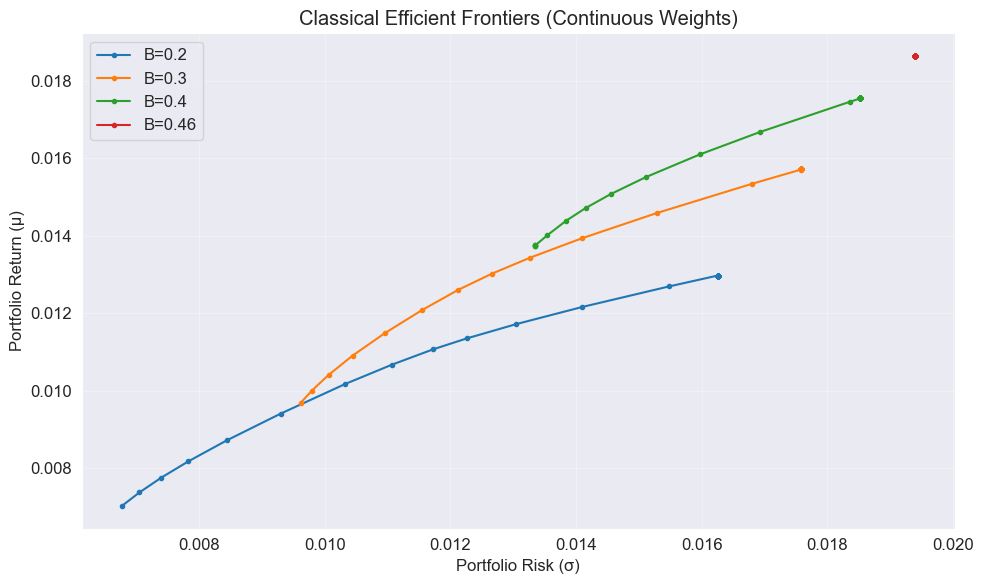

In [12]:
def markowitz_optimize(mu, cov, w_min, w_max, q, budget=None):
    """Classical continuous Markowitz optimization."""
    if budget is None:
        budget = w_max.sum()
    n = len(mu)
    constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - budget}]
    bounds = [(0, wm) for wm in w_max]
    w0 = np.clip(np.full(n, budget/n), 0, w_max)
    w0 = w0 / w0.sum() * budget
    
    res = minimize(lambda w: q * w @ cov @ w - mu @ w, w0,
                  method='SLSQP', bounds=bounds, constraints=constraints)
    return res.x, mu @ res.x, np.sqrt(res.x @ cov @ res.x)

# Sweep risk aversion q for efficient frontier
frontier = []
for q_val in np.logspace(-1, 2, 40):
    for B_val in [0.20, 0.30, 0.40, 0.46]:
        w_opt, ret, risk = markowitz_optimize(mu, cov4, np.zeros(4), w_max, q_val, B_val)
        frontier.append({'q': q_val, 'B': B_val, 'return': ret, 'risk': risk, 'weights': w_opt})

frontier_df = pd.DataFrame(frontier)

fig, ax = plt.subplots(figsize=(10, 6))
for B_val in [0.20, 0.30, 0.40, 0.46]:
    sub = frontier_df[frontier_df['B'] == B_val]
    ax.plot(sub['risk'], sub['return'], 'o-', markersize=3, label=f'B={B_val}')
ax.set_xlabel('Portfolio Risk (σ)')
ax.set_ylabel('Portfolio Return (μ)')
ax.set_title('Classical Efficient Frontiers (Continuous Weights)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 1.6 Build the QUBO Matrix (8×8)

The QUBO objective in terms of qubit variables:

$$\min_x \; q \sum_{i,j} \sum_{b_i, b_j} \sigma_{ij} \, c_{2i+b_i} \, c_{2j+b_j} \, x_{2i+b_i} \, x_{2j+b_j} \;-\; \sum_p \mu_{a(p)} \, c_p \, x_p \;+\; \lambda \left(\sum_p c_p \, x_p - B\right)^2$$

This expands to $\mathbf{x}^T Q \mathbf{x} + \text{offset}$ where $Q$ is 8×8.

In [13]:
def build_qubo_multilot(mu, cov, w_max, q_risk, lam, B, K=3):
    """
    Build 8×8 QUBO for 4 assets × 2 qubits per asset.
    
    Encoding:
        lot_count_i = x_{2i} + 2 * x_{2i+1}     (0, 1, 2, or 3 lots)
        weight_i    = (lot_count_i / K) * w_max_i
    
    Parameters
    ----------
    mu      : (4,) expected returns per asset
    cov     : (4,4) covariance matrix
    w_max   : (4,) max weight per asset
    q_risk  : risk aversion parameter
    lam     : penalty strength for budget constraint
    B       : target total portfolio weight (budget)
    K       : max lots (default 3)
    
    Returns
    -------
    Q       : (8,8) QUBO matrix
    offset  : constant term λB²
    c       : (8,) weight coefficients per qubit
    """
    n_assets = len(mu)
    n_qubits = 2 * n_assets
    
    # Weight coefficient per qubit
    c = np.zeros(n_qubits)
    for i in range(n_assets):
        c[2*i]     = w_max[i] / K
        c[2*i + 1] = 2 * w_max[i] / K
    
    Q = np.zeros((n_qubits, n_qubits))
    
    # Term 1: Risk — q * Σ_{ij} σ_{ij} * w_i * w_j
    for i in range(n_assets):
        for j in range(n_assets):
            for bi in range(2):
                for bj in range(2):
                    p, r = 2*i + bi, 2*j + bj
                    Q[p][r] += q_risk * cov[i][j] * c[p] * c[r]
    
    # Term 2: Return — -Σ_p μ_{asset(p)} * c_p * x_p
    for i in range(n_assets):
        for b in range(2):
            p = 2*i + b
            Q[p][p] -= mu[i] * c[p]
    
    # Term 3: Budget penalty — λ * (Σ_p c_p * x_p - B)²
    for p in range(n_qubits):
        for r in range(n_qubits):
            Q[p][r] += lam * c[p] * c[r]
        Q[p][p] -= 2 * lam * B * c[p]
    
    offset = lam * B**2
    Q = (Q + Q.T) / 2  # ensure symmetry
    
    return Q, offset, c


print('build_qubo_multilot() defined.')

build_qubo_multilot() defined.


In [14]:
# Build QUBO with chosen parameters
q_risk = 1.0    # risk aversion
lam    = 10.0   # budget penalty strength
B      = 0.30   # target budget (good for non-trivial landscape)

Q8, offset8, c_coeffs = build_qubo_multilot(mu, cov4, w_max, q_risk, lam, B)

print(f'QUBO Parameters: q={q_risk}, λ={lam}, B={B}')
print(f'Offset (λB²) = {offset8:.4f}')
print(f'\n8×8 QUBO Matrix Q:')
print(np.round(Q8, 5))

QUBO Parameters: q=1.0, λ=10.0, B=0.3
Offset (λB²) = 0.9000

8×8 QUBO Matrix Q:
[[-0.15506  0.01426  0.00533  0.01067  0.01067  0.02133  0.01778  0.03556]
 [ 0.01426 -0.29586  0.01067  0.02133  0.02133  0.04267  0.03556  0.07111]
 [ 0.00533  0.01067 -0.11745  0.00801  0.008    0.016    0.01333  0.02667]
 [ 0.01067  0.02133  0.00801 -0.2269   0.016    0.032    0.02667  0.05333]
 [ 0.01067  0.02133  0.008    0.016   -0.22533  0.03201  0.02667  0.05333]
 [ 0.02133  0.04267  0.016    0.032    0.03201 -0.41865  0.05333  0.10667]
 [ 0.01778  0.03556  0.01333  0.02667  0.02667  0.05333 -0.35677  0.0889 ]
 [ 0.03556  0.07111  0.02667  0.05333  0.05333  0.10667  0.0889  -0.62464]]


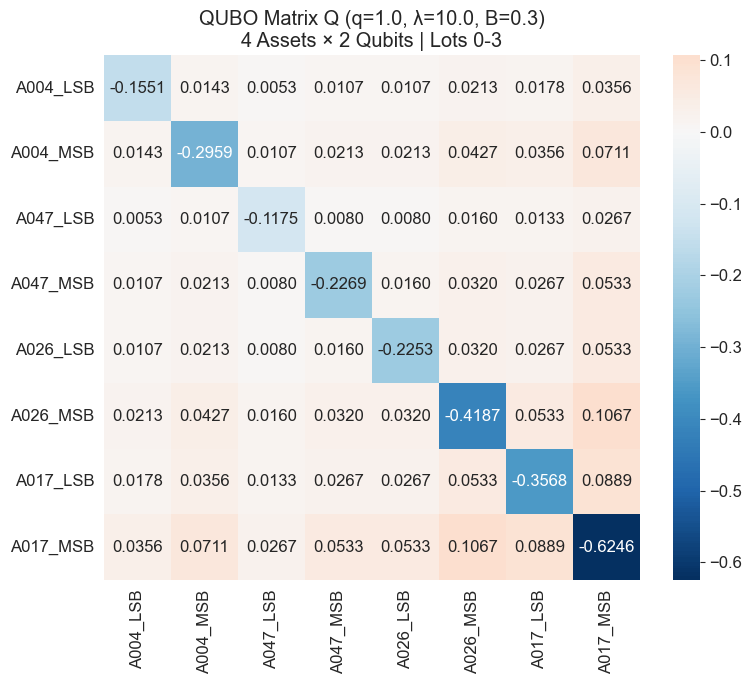

In [15]:
# Visualize the QUBO matrix
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(Q8, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            xticklabels=qubit_labels, yticklabels=qubit_labels, ax=ax)
ax.set_title(f'QUBO Matrix Q (q={q_risk}, λ={lam}, B={B})\n'
             f'4 Assets × 2 Qubits | Lots 0-3')
plt.tight_layout()
plt.show()

## 1.7 Brute-Force Ground Truth (All 256 Solutions)

In [16]:
def brute_force_multilot(Q, offset, mu, cov, w_max, K=3):
    """Enumerate all 2^8 = 256 binary configurations and decode."""
    n_assets = len(mu)
    n_qubits = 2 * n_assets
    results = []
    
    for bits in range(2**n_qubits):
        x = np.array([(bits >> i) & 1 for i in range(n_qubits)], dtype=float)
        
        # Decode lots and weights
        lots = [int(x[2*i]) + 2*int(x[2*i+1]) for i in range(n_assets)]
        weights = np.array([lots[i] * w_max[i] / K for i in range(n_assets)])
        
        obj = float(x @ Q @ x + offset)
        ret = float(mu @ weights)
        risk = float(np.sqrt(max(weights @ cov @ weights, 0)))
        
        results.append({
            'x': x.astype(int).tolist(),
            'lots': lots,
            'weights': np.round(weights, 4).tolist(),
            'total_weight': round(weights.sum(), 4),
            'return': round(ret, 6),
            'risk': round(risk, 6),
            'objective': round(obj, 6)
        })
    
    return sorted(results, key=lambda r: r['objective'])


all_results = brute_force_multilot(Q8, offset8, mu, cov4, w_max)

print(f'=== Top 15 Solutions (out of 256) ===')
print(f'Budget target B = {B}')
print(f'{"Rank":>4} {"Qubit State":>24} {"Lots":>14} {"Σw":>7} {"Return":>9} {"Risk":>9} {"Objective":>11}')
print('-' * 85)
for rank, r in enumerate(all_results[:15]):
    print(f"{rank+1:>4} {str(r['x']):>24} {str(r['lots']):>14} {r['total_weight']:>7.4f} "
          f"{r['return']:>9.6f} {r['risk']:>9.6f} {r['objective']:>11.6f}")

=== Top 15 Solutions (out of 256) ===
Budget target B = 0.3
Rank              Qubit State           Lots      Σw    Return      Risk   Objective
-------------------------------------------------------------------------------------
   1 [1, 1, 0, 1, 1, 1, 1, 0]   [3, 2, 3, 1]  0.3067  0.014735  0.016876   -0.014006
   2 [0, 1, 1, 1, 1, 1, 1, 0]   [2, 3, 3, 1]  0.3000  0.013999  0.014213   -0.013797
   3 [1, 1, 1, 1, 0, 1, 1, 0]   [3, 3, 2, 1]  0.2867  0.014859  0.016926   -0.012795
   4 [1, 1, 1, 1, 1, 0, 0, 1]   [3, 3, 1, 2]  0.3133  0.014745  0.016954   -0.012680
   5 [1, 1, 0, 1, 1, 0, 0, 1]   [3, 2, 1, 2]  0.2933  0.013285  0.016049   -0.012583
   6 [0, 1, 0, 1, 0, 1, 0, 1]   [2, 2, 2, 2]  0.3067  0.012425  0.012931   -0.011814
   7 [1, 0, 1, 1, 0, 1, 0, 1]   [1, 3, 2, 2]  0.3000  0.011690  0.011282   -0.011563
   8 [1, 1, 1, 0, 0, 0, 1, 1]   [3, 1, 0, 3]  0.3000  0.011711  0.016028   -0.011454
   9 [1, 1, 1, 0, 1, 1, 1, 0]   [3, 1, 3, 1]  0.2867  0.013275  0.016253   -0.011233
  10

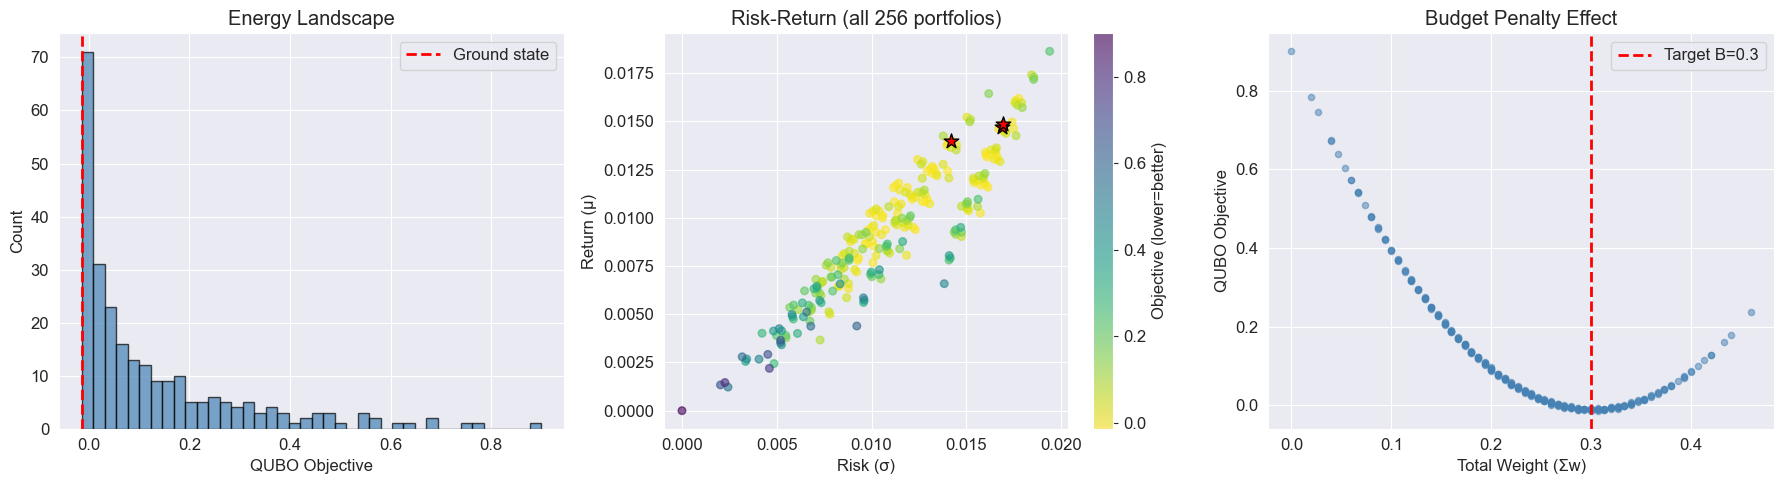

In [17]:
# Visualize the energy landscape
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Objective distribution
objectives = [r['objective'] for r in all_results]
axes[0].hist(objectives, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(all_results[0]['objective'], color='red', linestyle='--', lw=2, label='Ground state')
axes[0].set_xlabel('QUBO Objective')
axes[0].set_ylabel('Count')
axes[0].set_title('Energy Landscape')
axes[0].legend()

# Plot 2: Return vs Risk colored by objective
rets = [r['return'] for r in all_results]
risks = [r['risk'] for r in all_results]
objs = [r['objective'] for r in all_results]
scatter = axes[1].scatter(risks, rets, c=objs, cmap='viridis_r', alpha=0.6, s=30)
plt.colorbar(scatter, ax=axes[1], label='Objective (lower=better)')
for i in range(3):  # mark top 3
    axes[1].scatter(all_results[i]['risk'], all_results[i]['return'], 
                   c='red', s=120, marker='*', edgecolors='black', zorder=5)
axes[1].set_xlabel('Risk (σ)')
axes[1].set_ylabel('Return (μ)')
axes[1].set_title('Risk-Return (all 256 portfolios)')

# Plot 3: Total weight vs Objective
total_ws = [r['total_weight'] for r in all_results]
axes[2].scatter(total_ws, objs, alpha=0.5, s=20, c='steelblue')
axes[2].axvline(B, color='red', linestyle='--', lw=2, label=f'Target B={B}')
axes[2].set_xlabel('Total Weight (Σw)')
axes[2].set_ylabel('QUBO Objective')
axes[2].set_title('Budget Penalty Effect')
axes[2].legend()

plt.tight_layout()
plt.show()

In [18]:
# Show how optimal allocation changes with budget
print('=== Optimal Portfolio vs Budget Target ===')
print(f'{"B":>5} {"Lots":>14} {"A004":>7} {"A047":>7} {"A026":>7} {"A017":>7} {"Σw":>7} {"Ret":>8} {"Risk":>8}')
print('-' * 80)

for B_val in [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.46]:
    Q_tmp, off_tmp, _ = build_qubo_multilot(mu, cov4, w_max, q_risk, lam, B_val)
    results_tmp = brute_force_multilot(Q_tmp, off_tmp, mu, cov4, w_max)
    best = results_tmp[0]
    print(f"{B_val:>5.2f} {str(best['lots']):>14} "
          f"{best['weights'][0]:>7.4f} {best['weights'][1]:>7.4f} "
          f"{best['weights'][2]:>7.4f} {best['weights'][3]:>7.4f} "
          f"{best['total_weight']:>7.4f} {best['return']:>8.5f} {best['risk']:>8.5f}")

=== Optimal Portfolio vs Budget Target ===
    B           Lots    A004    A047    A026    A017      Σw      Ret     Risk
--------------------------------------------------------------------------------
 0.10   [3, 1, 0, 0]  0.0800  0.0200  0.0000  0.0000  0.1000  0.00805  0.01410
 0.15   [2, 3, 1, 0]  0.0533  0.0600  0.0400  0.0000  0.1533  0.01011  0.01206
 0.20   [3, 2, 2, 0]  0.0800  0.0400  0.0800  0.0000  0.2000  0.01218  0.01568
 0.25   [3, 3, 3, 0]  0.0800  0.0600  0.1200  0.0000  0.2600  0.01497  0.01741
 0.30   [3, 2, 3, 1]  0.0800  0.0400  0.1200  0.0667  0.3067  0.01473  0.01688
 0.35   [3, 3, 2, 2]  0.0800  0.0600  0.0800  0.1333  0.3533  0.01608  0.01760
 0.40   [3, 3, 3, 2]  0.0800  0.0600  0.1200  0.1333  0.3933  0.01742  0.01844
 0.46   [3, 3, 3, 3]  0.0800  0.0600  0.1200  0.2000  0.4600  0.01864  0.01940


## 1.8 QUBO → Ising Conversion

Convert $x_i \in \{0,1\}$ → $s_i \in \{-1,+1\}$ via $x_i = (1 + s_i)/2$

$$H_{\text{Ising}} = \sum_{i<j} J_{ij} \, s_i s_j \;+\; \sum_i h_i \, s_i \;+\; \text{const}$$

In [19]:
def qubo_to_ising(Q):
    """Convert QUBO matrix to Ising Hamiltonian (J, h, offset)."""
    n = Q.shape[0]
    J = np.zeros((n, n))
    h = np.zeros(n)
    ising_offset = 0.0
    
    for i in range(n):
        for j in range(i+1, n):
            J[i][j] = Q[i][j] / 4.0
        h[i] = Q[i][i] / 2.0 + sum(Q[i][j] / 4.0 for j in range(n) if j != i)
        ising_offset += Q[i][i] / 4.0
    
    ising_offset += sum(Q[i][j] / 4.0 for i in range(n) for j in range(i+1, n))
    return J, h, ising_offset


J8, h8, ising_offset = qubo_to_ising(Q8)

print('=== Ising Hamiltonian ===')
print(f'\nLocal fields h:')
for i in range(n_qubits):
    print(f'  h[{i}] ({qubit_labels[i]:>10}) = {h8[i]:>10.6f}')

print(f'\nCouplings J:')
for i in range(n_qubits):
    for j in range(i+1, n_qubits):
        print(f'  J[{i},{j}] ({qubit_labels[i]:>10} — {qubit_labels[j]:<10}) = {J8[i][j]:>10.6f}')

=== Ising Hamiltonian ===

Local fields h:
  h[0] (  A004_LSB) =  -0.048631
  h[1] (  A004_MSB) =  -0.093696
  h[2] (  A047_LSB) =  -0.036724
  h[3] (  A047_MSB) =  -0.071445
  h[4] (  A026_LSB) =  -0.070662
  h[5] (  A026_MSB) =  -0.133323
  h[6] (  A017_LSB) =  -0.112826
  h[7] (  A017_MSB) =  -0.203428

Couplings J:
  J[0,1] (  A004_LSB — A004_MSB  ) =   0.003566
  J[0,2] (  A004_LSB — A047_LSB  ) =   0.001333
  J[0,3] (  A004_LSB — A047_MSB  ) =   0.002667
  J[0,4] (  A004_LSB — A026_LSB  ) =   0.002667
  J[0,5] (  A004_LSB — A026_MSB  ) =   0.005334
  J[0,6] (  A004_LSB — A017_LSB  ) =   0.004444
  J[0,7] (  A004_LSB — A017_MSB  ) =   0.008889
  J[1,2] (  A004_MSB — A047_LSB  ) =   0.002667
  J[1,3] (  A004_MSB — A047_MSB  ) =   0.005334
  J[1,4] (  A004_MSB — A026_LSB  ) =   0.005334
  J[1,5] (  A004_MSB — A026_MSB  ) =   0.010667
  J[1,6] (  A004_MSB — A017_LSB  ) =   0.008889
  J[1,7] (  A004_MSB — A017_MSB  ) =   0.017778
  J[2,3] (  A047_LSB — A047_MSB  ) =   0.002003
  J[2,4

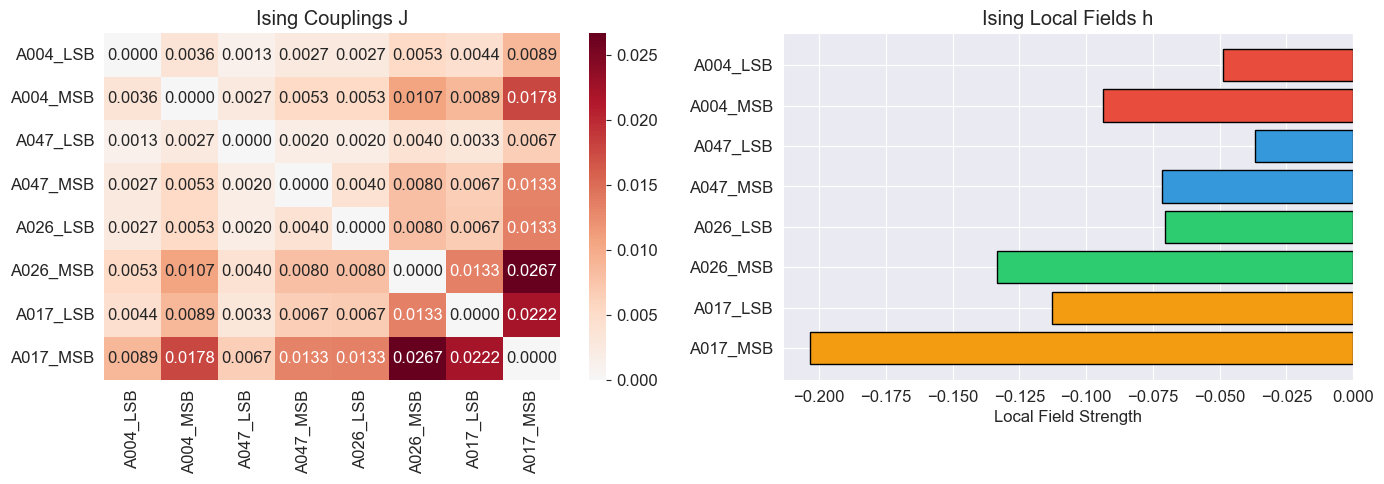

Note: All J > 0 (anti-ferromagnetic) → qubits prefer opposite spins
      All h < 0 → qubits biased toward s=+1 (x=1, include the asset)
      Stronger |h| on Gov Bonds (q6,q7) → optimizer prefers bonds for budget compliance


In [20]:
# Visualize Ising coupling structure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# J matrix heatmap
J_full = J8 + J8.T
sns.heatmap(J_full, annot=True, fmt='.4f', cmap='RdBu_r', center=0,
            xticklabels=qubit_labels, yticklabels=qubit_labels, ax=axes[0])
axes[0].set_title('Ising Couplings J')

# h fields bar chart
colors = ['#e74c3c', '#e74c3c', '#3498db', '#3498db', 
          '#2ecc71', '#2ecc71', '#f39c12', '#f39c12']
axes[1].barh(range(n_qubits), h8, color=colors, edgecolor='black')
axes[1].set_yticks(range(n_qubits))
axes[1].set_yticklabels(qubit_labels)
axes[1].set_xlabel('Local Field Strength')
axes[1].set_title('Ising Local Fields h')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print('Note: All J > 0 (anti-ferromagnetic) → qubits prefer opposite spins')
print('      All h < 0 → qubits biased toward s=+1 (x=1, include the asset)')
print('      Stronger |h| on Gov Bonds (q6,q7) → optimizer prefers bonds for budget compliance')

## 1.9 Scenario-Based Validation

Optimal portfolio: lots=[3, 2, 3, 1], weights=[0.08, 0.04, 0.12, 0.0667]

--- Scenario Analysis (1,200 sims) ---
Mean return:  0.000082
Std dev:      0.001079
VaR (95%):    -0.001784
CVaR (95%):   -0.002210
Worst case:   -0.003514
Best case:    0.003349


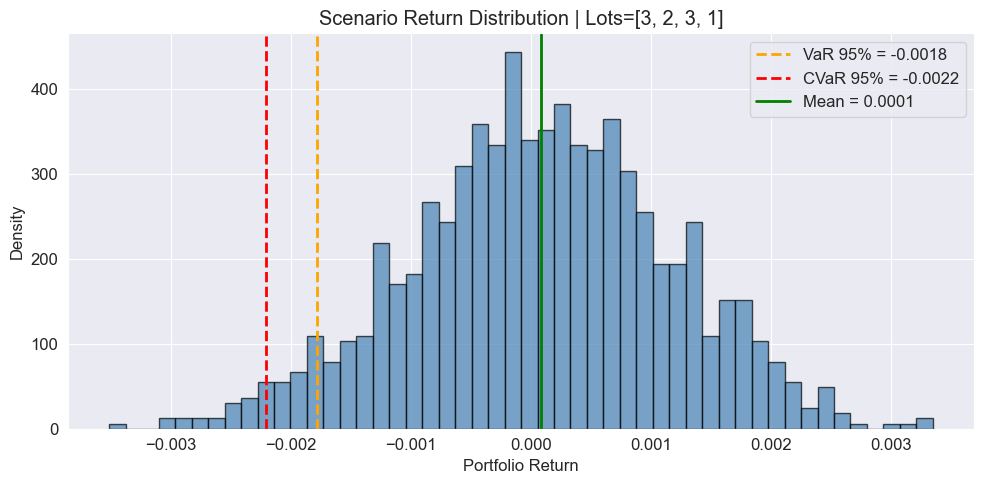

In [21]:
best = all_results[0]
w_opt = np.array(best['weights'])

# Portfolio returns across 1,200 scenarios
scenario_rets = scenarios[sel4_ids].values @ w_opt

var_95 = np.percentile(scenario_rets, 5)
cvar_95 = scenario_rets[scenario_rets <= var_95].mean()

print(f'Optimal portfolio: lots={best["lots"]}, weights={best["weights"]}')
print(f'\n--- Scenario Analysis (1,200 sims) ---')
print(f'Mean return:  {scenario_rets.mean():.6f}')
print(f'Std dev:      {scenario_rets.std():.6f}')
print(f'VaR (95%):    {var_95:.6f}')
print(f'CVaR (95%):   {cvar_95:.6f}')
print(f'Worst case:   {scenario_rets.min():.6f}')
print(f'Best case:    {scenario_rets.max():.6f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(scenario_rets, bins=50, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(var_95, color='orange', ls='--', lw=2, label=f'VaR 95% = {var_95:.4f}')
ax.axvline(cvar_95, color='red', ls='--', lw=2, label=f'CVaR 95% = {cvar_95:.4f}')
ax.axvline(scenario_rets.mean(), color='green', lw=2, label=f'Mean = {scenario_rets.mean():.4f}')
ax.set_xlabel('Portfolio Return')
ax.set_ylabel('Density')
ax.set_title(f'Scenario Return Distribution | Lots={best["lots"]}')
ax.legend()
plt.tight_layout()
plt.show()

## 1.10 Save Handoff for Step 2 (Bloqade)

Everything the quantum circuit needs:

In [22]:
handoff = {
    'encoding': '4 assets × 2 qubits each | lots = x_LSB + 2*x_MSB | weight = (lots/3)*w_max',
    'assets': sel4_ids,
    'sectors': sectors4,
    'mu': mu.tolist(),
    'w_max': w_max.tolist(),
    'cov_matrix_4x4': cov4.tolist(),
    'qubit_labels': qubit_labels,
    'qubit_coefficients': c_coeffs.tolist(),
    'Q_matrix_8x8': Q8.tolist(),
    'qubo_offset': offset8,
    'J_matrix_8x8': J8.tolist(),
    'h_fields': h8.tolist(),
    'ising_offset': ising_offset,
    'params': {'q': q_risk, 'lambda': lam, 'B': B, 'K': K},
    'ground_truth': all_results[0],
    'top_10': all_results[:10]
}

with open('step2_handoff_multilot.json', 'w') as f:
    json.dump(handoff, f, indent=2)

print('=== Saved step2_handoff_multilot.json ===')
print(f'\nGround truth:')
print(f'  Qubits:  {all_results[0]["x"]}')
print(f'  Lots:    {all_results[0]["lots"]}  → {dict(zip(sel4_ids, all_results[0]["lots"]))}')
print(f'  Weights: {all_results[0]["weights"]}')
print(f'  Return:  {all_results[0]["return"]}')
print(f'  Risk:    {all_results[0]["risk"]}')
print(f'  QUBO obj:{all_results[0]["objective"]}')
print(f'\n→ Ready for Step 2: QAOA on Bloqade with 8 qubits!')

=== Saved step2_handoff_multilot.json ===

Ground truth:
  Qubits:  [1, 1, 0, 1, 1, 1, 1, 0]
  Lots:    [3, 2, 3, 1]  → {'A004': 3, 'A047': 2, 'A026': 3, 'A017': 1}
  Weights: [0.08, 0.04, 0.12, 0.0667]
  Return:  0.014735
  Risk:    0.016876
  QUBO obj:-0.014006

→ Ready for Step 2: QAOA on Bloqade with 8 qubits!
